In [2]:
import torch
import numpy as np
import ioptics
from ioptics import OpticalNN, ClementsMesh, SquareActivation, AbsSquared
from ioptics import ModelOutputDomain, SimulationMode
from torch.optim import Adam
from torch import autograd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import utils

In [3]:
BASE_SEED = 20260415
torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

def compute_accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()

In [7]:
# 1. Data Preparation
iris = load_iris()
X, y = iris.data, iris.target

# Keep classes 0 and 1 only
mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]

# Normalize inputs
X_normalized = utils.normalize_inputs(X, 5, P0=130)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, stratify=y, test_size=0.2, random_state=BASE_SEED
)

# Convert to tensors
X_train_tensor = torch.tensor(X_train / 2, dtype=torch.complex128, requires_grad=True)
X_test_tensor = torch.tensor(X_test / 2, dtype=torch.complex128, requires_grad=False)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


In [147]:
# 3. Simulator Configuration
from ioptics import SimulatorConfig
sim_cfg = SimulatorConfig(
    mzi_insertion_loss=1.2,
    coupling_loss=0.5,
    laser_noise=True,
    detector_noise=True,
    model_output_domain=ModelOutputDomain.POWER.value
)
simulator = ioptics.simulator(config=sim_cfg)

In [159]:
# 2. Model Definitions
# Use a common initialization source
model_dig_async = OpticalNN(
    ClementsMesh(5),
    SquareActivation(),
    ClementsMesh(5, output_ports=slice(0, 2)),
    AbsSquared(),
)

model_phy_async = OpticalNN(
    ClementsMesh(5, phase_noise_std=0.01),
    SquareActivation(),
    ClementsMesh(5, output_ports=slice(0, 2), phase_noise_std=0.01),
    AbsSquared(),
)
model_phy_async.load_state_dict(model_dig_async.state_dict())

model_phy_only = OpticalNN(
    ClementsMesh(5, phase_noise_std=0.01),
    SquareActivation(),
    ClementsMesh(5, output_ports=slice(0, 2), phase_noise_std=0.01),
    AbsSquared(),
)
model_phy_only.load_state_dict(model_dig_async.state_dict())

criterion = torch.nn.CrossEntropyLoss()
epochs = 30


In [160]:
# --- Async Hybrid Training ---
print("Training Async-Hybrid...")
optim_dig = Adam(model_dig_async.parameters(), lr=0.01)
optim_phy_async = Adam(model_phy_async.parameters(), lr=0.01)
asy_acc = []
asy_acc_test = []

for e in range(epochs):
    optim_dig.zero_grad()
    optim_phy_async.zero_grad()

    output_phy = simulator.run(
        X_train_tensor,
        model_phy_async,
        seed=BASE_SEED + e,
        mode=SimulationMode.STOCHASTIC.value,
        model_output_domain=ModelOutputDomain.POWER.value
    )

    loss_phy = criterion(output_phy, y_train)
    grad_phy = autograd.grad(loss_phy, output_phy, retain_graph=True)[0]

    output_dig = model_dig_async(X_train_tensor)
    output_dig.backward(grad_phy, retain_graph=True)

    for p_dig, p_phy in zip(model_dig_async.parameters(), model_phy_async.parameters()):
        if p_dig.grad is not None:
            p_phy.grad = p_dig.grad.clone()

    optim_dig.zero_grad()
    loss_dig = criterion(output_dig, y_train)
    loss_dig.backward()

    for p_dig, p_phy in zip(model_dig_async.parameters(), model_phy_async.parameters()):
        if p_phy.grad is not None and p_dig.grad is not None:
            p_phy.grad = (p_phy.grad + p_dig.grad) / 2

    optim_dig.step()
    optim_phy_async.step()

    asy_acc.append(compute_accuracy(output_phy, y_train))
    if e == 0 or (e + 1) % 1 == 0:
        print(f"Epoch {e+1:3d} | Async Acc: {asy_acc[-1]:.4f}")

    with torch.no_grad():
        out_asy = simulator.run(X_test_tensor, model_phy_async, seed=BASE_SEED, mode=SimulationMode.STOCHASTIC.value, model_output_domain=ModelOutputDomain.POWER.value)

        test_acc_asy = compute_accuracy(out_asy, y_test)
        asy_acc_test.append(test_acc_asy)

    print(f"Test Accuracy (Async-Hybrid): {test_acc_asy:.4f}")

# --- Physical-Only Training ---
print("\nTraining Physical-Only...")
optim_phy_only = Adam(model_phy_only.parameters(), lr=0.01)
phy_only_acc = []

for e in range(epochs):
    optim_phy_only.zero_grad()

    output_phy = simulator.run(
        X_train_tensor,
        model_phy_only,
        seed=BASE_SEED + 10000 + e,
        mode=SimulationMode.STOCHASTIC.value,
        model_output_domain=ModelOutputDomain.POWER.value
    )

    loss_phy = criterion(output_phy, y_train)
    loss_phy.backward()
    optim_phy_only.step()

    phy_only_acc.append(compute_accuracy(output_phy, y_train))
    if e == 0 or (e + 1) % 1 == 0:
        print(f"Epoch {e+1:3d} | Phy-Only Acc: {phy_only_acc[-1]:.4f}")

# 4. Evaluation
print("\nEvaluating on Test Set...")
with torch.no_grad():
    out_asy = simulator.run(X_test_tensor, model_phy_async, seed=BASE_SEED, mode=SimulationMode.STOCHASTIC.value, model_output_domain=ModelOutputDomain.POWER.value)
    out_phy = simulator.run(X_test_tensor, model_phy_only, seed=BASE_SEED, mode=SimulationMode.STOCHASTIC.value, model_output_domain=ModelOutputDomain.POWER.value)

    test_acc_asy = compute_accuracy(out_asy, y_test)
    test_acc_phy = compute_accuracy(out_phy, y_test)

print(f"Test Accuracy (Async-Hybrid): {test_acc_asy:.4f}")
print(f"Test Accuracy (Phy-Only):     {test_acc_phy:.4f}")

Training Async-Hybrid...
Epoch   1 | Async Acc: 0.5000
Test Accuracy (Async-Hybrid): 0.5000
Epoch   2 | Async Acc: 0.5000
Test Accuracy (Async-Hybrid): 0.5000
Epoch   3 | Async Acc: 0.5000
Test Accuracy (Async-Hybrid): 0.5000
Epoch   4 | Async Acc: 0.5125
Test Accuracy (Async-Hybrid): 0.7000
Epoch   5 | Async Acc: 0.6250
Test Accuracy (Async-Hybrid): 0.7000
Epoch   6 | Async Acc: 0.7500
Test Accuracy (Async-Hybrid): 0.8000
Epoch   7 | Async Acc: 0.8625
Test Accuracy (Async-Hybrid): 0.7500
Epoch   8 | Async Acc: 0.7875
Test Accuracy (Async-Hybrid): 0.6500
Epoch   9 | Async Acc: 0.7625
Test Accuracy (Async-Hybrid): 0.6500
Epoch  10 | Async Acc: 0.7625
Test Accuracy (Async-Hybrid): 0.8500
Epoch  11 | Async Acc: 0.8375
Test Accuracy (Async-Hybrid): 0.8000
Epoch  12 | Async Acc: 0.9000
Test Accuracy (Async-Hybrid): 0.9000
Epoch  13 | Async Acc: 0.9125
Test Accuracy (Async-Hybrid): 0.9000
Epoch  14 | Async Acc: 0.9500
Test Accuracy (Async-Hybrid): 0.9000
Epoch  15 | Async Acc: 0.9375
Test Ac

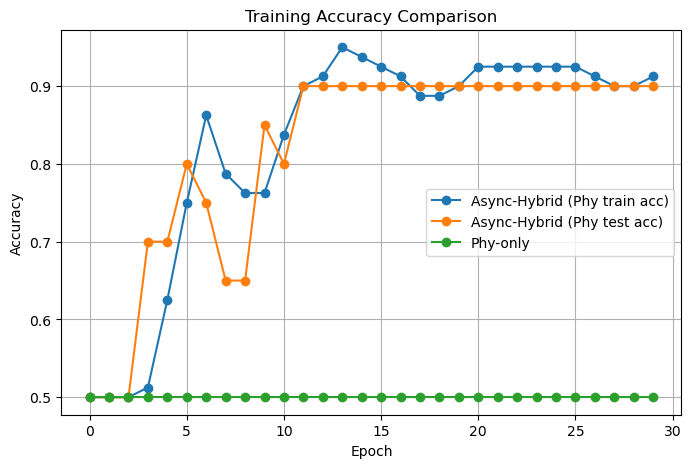

In [163]:
# 5. Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), asy_acc, label="Async-Hybrid (Phy train acc)", marker="o", markevery=1)
plt.plot(range(epochs), asy_acc_test, label="Async-Hybrid (Phy test acc)", marker="o", markevery=1)
plt.plot(range(epochs), phy_only_acc, label="Phy-only", marker="o", markevery=1)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.savefig("async_vs_phy_only_accuracy.png", dpi=150)
plt.show()
